In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
from matplotlib import pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import statsmodels.api as sm
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

## **Data ingestion**

In [ ]:
# CPI data from FRED (Federal Reserve Economic Data)
cpi_data = pdr.DataReader('CPIAUCSL', 'fred', start='2000-01-01', end='2024-12-31')
last_cpi = cpi_data['CPIAUCSL'].iloc[-1]
cpi_data['CPI_rescaled'] = cpi_data['CPIAUCSL'] / last_cpi

# 1
wti_spot = pd.read_csv('/content/Cushing_OK_WTI_Spot_Price_FOB.csv', on_bad_lines='skip')
wti_spot['Month'] = pd.to_datetime(wti_spot['Month'], format='%b-%y')
wti_spot = wti_spot[(wti_spot['Month'].dt.year >= 2000) & (wti_spot['Month'].dt.year <= 2024)]
wti_spot.index = range(1, len(wti_spot) + 1)

# 2
ng_spot = pd.read_csv('/content/Henry_Hub_Natural_Gas_Spot_Price.csv')
ng_spot['Month'] = pd.to_datetime(ng_spot['Month'], format='%b-%y')
ng_spot = ng_spot[(ng_spot['Month'].dt.year >= 2000) & (ng_spot['Month'].dt.year <= 2024)]
ng_spot.index = range(1, len(wti_spot) + 1)

wti_spot = pd.merge(wti_spot, cpi_data[['CPI_rescaled']], left_on='Month', right_index=True, how='left')
ng_spot = pd.merge(ng_spot, cpi_data[['CPI_rescaled']], left_on='Month', right_index=True, how='left')

# Deflate WTI spot price
wti_spot['wti_spot_real'] = wti_spot['wti_spot'] / wti_spot['CPI_rescaled']

# Deflate natural gas spot price
ng_spot['ng_spot_real'] = ng_spot['ng_spot'] / ng_spot['CPI_rescaled']


## **Visualization**

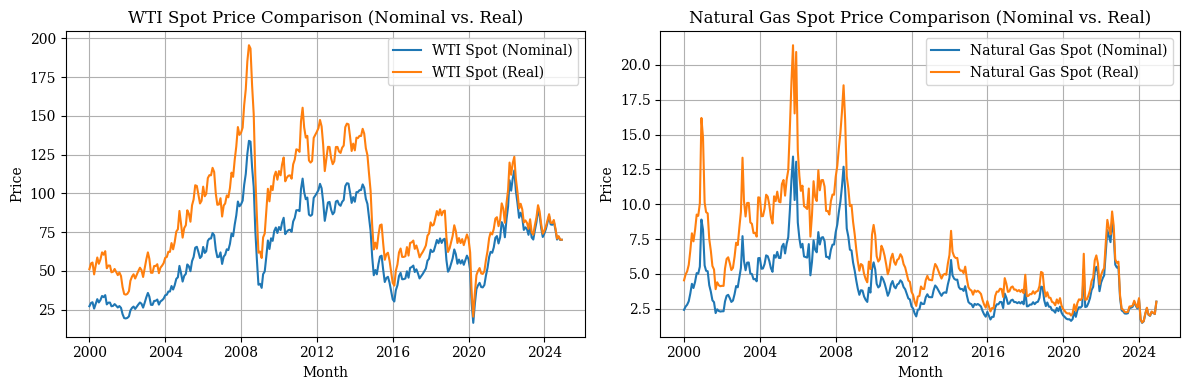

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))  # 1 row, 2 columns

# WTI Spot Price
axes[0].plot(wti_spot['Month'], wti_spot['wti_spot'], label='WTI Spot (Nominal)')
axes[0].plot(wti_spot['Month'], wti_spot['wti_spot_real'], label='WTI Spot (Real)')
axes[0].set_title('WTI Spot Price Comparison (Nominal vs. Real)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Price')
axes[0].legend()
axes[0].grid(True)

# Natural Gas Spot Price
axes[1].plot(ng_spot['Month'], ng_spot['ng_spot'], label='Natural Gas Spot (Nominal)')
axes[1].plot(ng_spot['Month'], ng_spot['ng_spot_real'], label='Natural Gas Spot (Real)')
axes[1].set_title('Natural Gas Spot Price Comparison (Nominal vs. Real)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Price')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
wti_spot = wti_spot[['Month', 'wti_spot_real']]
wti_spot

,Month,wti_spot_real
1,2024-12-01,70.120000
2,2024-11-01,70.205088
3,2024-10-01,72.455160
4,2024-09-01,70.853943
5,2024-08-01,77.527522
...,...,...
296,2000-05-01,53.409990
297,2000-04-01,47.798415
298,2000-03-01,55.422652
299,2000-02-01,54.870589


In [ ]:
# 3
gepu = pd.read_excel('/content/Global_Policy_Uncertainty_Data.xlsx')
gepu = gepu.dropna(subset=['Year', 'Month']).copy()
gepu['Year'] = pd.to_numeric(gepu['Year'], errors='coerce')
gepu = gepu[(gepu['Year'] >= 2000) & (gepu['Year'] <= 2024)]
gepu = gepu.sort_values(by=['Year', 'Month'], ascending=False)
gepu = pd.DataFrame(gepu['GEPU_current'])
gepu.index = range(1, len(wti_spot) + 1)

# 4
wti_prod = pd.read_csv('/content/U.S._Field_Production_of_Crude_Oil.csv')
wti_prod = wti_prod.iloc[1:301:, :]

# 5
ng_prod = pd.read_csv('/content/U.S._Natural_Gas_Gross_Withdrawals.csv')
ng_prod['Month'] = pd.to_datetime(ng_prod['Month'], format='%b-%y')
ng_prod = ng_prod[(ng_prod['Month'].dt.year >= 2000) & (ng_prod['Month'].dt.year <= 2024)]

# 6
lng_export = pd.read_csv('/content/Liquefied_U.S._Natural_Gas_Exports.csv', skiprows=4)
lng_export['Month'] = pd.to_datetime(lng_export['Month'], format='%b %Y')
lng_export = lng_export[(lng_export['Month'].dt.year >= 2000) & (lng_export['Month'].dt.year <= 2024)]
# lng_export.set_index(lng_export['Month'], inplace=True)
lng_export.drop(columns=['Month'], inplace=True)
lng_export.columns = ["lng_export"]

# 7
oil_gas_rotary_rigs = pd.read_csv('/content/U.S._Crude_Oil_and_Natural_Gas_Rotary_Rigs_in_Operation.csv', skiprows = 4)
oil_gas_rotary_rigs['Month'] = pd.to_datetime(oil_gas_rotary_rigs['Month'], format='%b %Y')
oil_gas_rotary_rigs = oil_gas_rotary_rigs[(oil_gas_rotary_rigs['Month'].dt.year >= 2000) & (oil_gas_rotary_rigs['Month'].dt.year <= 2024)]
# oil_gas_rotary_rigs.set_index(oil_gas_rotary_rigs['Month'], inplace=True)
oil_gas_rotary_rigs.drop(columns=['Month'], inplace=True)
oil_gas_rotary_rigs.columns = ["oil_gas_rotary_rigs"]
oil_gas_rotary_rigs.index = range(1, len(oil_gas_rotary_rigs) + 1)
oil_gas_rotary_rigs

# 8
dry_ng_prod = pd.read_csv('/content/U.S._Dry_Natural_Gas_Production.csv', skiprows = 4)
dry_ng_prod['Month'] = pd.to_datetime(dry_ng_prod['Month'], format='%b %Y')
dry_ng_prod = dry_ng_prod[(dry_ng_prod['Month'].dt.year >= 2000) & (dry_ng_prod['Month'].dt.year <= 2024)]
# dry_ng_prod.set_index(dry_ng_prod['Month'], inplace=True)
dry_ng_prod.drop(columns=['Month'], inplace=True)
dry_ng_prod.columns = ["dry_ng_prod"]

# 9
ng_consumption = pd.read_csv('/content/U.S._Natural_Gas_Total_Consumption.csv', skiprows = 4)
ng_consumption['Month'] = pd.to_datetime(ng_consumption['Month'], format='%b %Y')
ng_consumption = ng_consumption[(ng_consumption['Month'].dt.year >= 2000) & (ng_consumption['Month'].dt.year <= 2024)]
# dry_ng_prod.set_index(dry_ng_prod['Month'], inplace=True)
ng_consumption.drop(columns=['Month'], inplace=True)
ng_consumption.columns = ["ng_consumption"]

# 10
indpro = pd.read_excel('/content/INDPRO.xlsx')
indpro['Month'] = pd.to_datetime(indpro['observation_date'], format='%b %Y')
indpro = indpro[(indpro['Month'].dt.year >= 2000) & (indpro['Month'].dt.year <= 2024)]
indpro = indpro.sort_values(by=['Month'], ascending=False)
indpro.index = range(1, len(indpro) + 1)
indpro.drop(columns=['observation_date', 'Month'], inplace=True)

# 11
vix = pd.read_csv('/content/VIXCLS.csv')
vix['observation_date'] = pd.to_datetime(vix['observation_date'])
vix.set_index('observation_date', inplace=True)
vix = vix[(vix.index.year >= 2000) & (vix.index.year <= 2024)]
vix_monthly = vix.resample('ME').last()
vix_monthly.sort_index(ascending=False, inplace=True)
vix_monthly.reset_index(inplace=True)
vix_monthly.index = range(1, len(indpro) + 1)
vix_monthly.drop(columns=['observation_date'], inplace=True)

data = pd.concat([wti_spot, ng_spot['ng_spot_real'], gepu, wti_prod['wti_prod'],
                  ng_prod['ng_prod'], lng_export, oil_gas_rotary_rigs,
                 dry_ng_prod, ng_consumption, indpro, vix_monthly], axis=1)
data.set_index(pd.to_datetime(data['Month'], format='%b-%y'), inplace=True)
data.drop(columns=['Month'], inplace=True)
print(data.head())

            wti_spot_real  ng_spot_real  GEPU_current  wti_prod  ng_prod  \
Month                                                                      
2024-12-01      70.120000      3.010000    377.073675    416988  3991323   
2024-11-01      70.205088      2.127731    365.206009    400561  3785867   
2024-10-01      72.455160      2.214215    223.640869    416953  3889052   
2024-09-01      70.853943      2.299929    223.007104    395541  3705158   
2024-08-01      77.527522      2.011995    225.378325    414270  3849811   

            lng_export  oil_gas_rotary_rigs  dry_ng_prod  ng_consumption  \
Month                                                                      
2024-12-01      410786                  589      3272746       3361414.0   
2024-11-01      376065                  584      3089788       2716094.0   
2024-10-01      376200                  585      3189491       2436261.0   
2024-09-01      363030                  587      3053998       2422962.0   
2024-08-01 

In [ ]:
data.shape

(300, 11)

## **Pearson's correlation**

In [ ]:
data.corr()

,wti_spot_real,ng_spot_real,GEPU_current,wti_prod,ng_prod,lng_export,oil_gas_rotary_rigs,dry_ng_prod,ng_consumption,INDPRO,VIXCLS
wti_spot_real,1.000000,0.279387,-0.186386,-0.227012,-0.115548,-0.152699,0.728622,-0.115442,-0.153040,0.273086,-0.115365
ng_spot_real,0.279387,1.000000,-0.566615,-0.648695,-0.629002,-0.414067,0.444965,-0.642209,-0.379818,-0.193975,0.029874
GEPU_current,-0.186386,-0.566615,1.000000,0.797342,0.841157,0.739885,-0.532600,0.840598,0.529117,0.357465,0.178713
wti_prod,-0.227012,-0.648695,0.797342,1.000000,0.975214,0.839883,-0.613278,0.977941,0.615534,0.647294,-0.165339
ng_prod,-0.115548,-0.629002,0.841157,0.975214,1.000000,0.893103,-0.562283,0.998630,0.628130,0.620885,-0.091816
lng_export,-0.152699,-0.414067,0.739885,0.839883,0.893103,1.000000,-0.600972,0.882200,0.556209,0.470842,-0.014854
oil_gas_rotary_rigs,0.728622,0.444965,-0.532600,-0.613278,-0.562283,-0.600972,1.000000,-0.558578,-0.365631,-0.019753,-0.029147
dry_ng_prod,-0.115442,-0.642209,0.840598,0.977941,0.998630,0.882200,-0.558578,1.000000,0.613197,0.621792,-0.095166
ng_consumption,-0.153040,-0.379818,0.529117,0.615534,0.628130,0.556209,-0.365631,0.613197,1.000000,0.421309,-0.047469
INDPRO,0.273086,-0.193975,0.357465,0.647294,0.620885,0.470842,-0.019753,0.621792,0.421309,1.000000,-0.453336


## **Variable identification for this work and log transform relevant variables**

In [ ]:
data = data[['wti_spot_real', 'wti_prod', 'INDPRO', 'ng_spot_real', 'lng_export', 'GEPU_current', 'VIXCLS']]

log_vars = ['wti_spot_real', 'wti_prod', 'INDPRO', 'ng_spot_real', 'lng_export']
data_log = data.copy()
for col in log_vars:
    data_log[col] = np.log(data_log[col])

data_log.head()

,wti_spot_real,wti_prod,INDPRO,ng_spot_real,lng_export,GEPU_current,VIXCLS
Month,,,,,,,
2024-12-01,4.250208,12.940813,4.635871,1.101940,12.925828,377.073675,17.35
2024-11-01,4.251421,12.900621,4.624599,0.755056,12.837517,365.206009,13.51
2024-10-01,4.282968,12.940729,4.627067,0.794898,12.837876,223.640869,23.16
2024-09-01,4.260621,12.888010,4.630793,0.832878,12.802241,223.007104,16.73
2024-08-01,4.350633,12.934273,4.634919,0.699127,12.803738,225.378325,15.00


## **Volatility of Volatility**

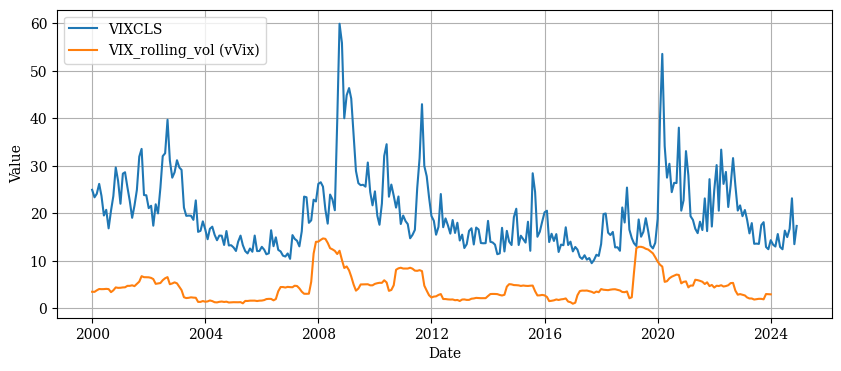

In [ ]:
data_log['VIX_rolling_vol'] = data_log['VIXCLS'].rolling(window=12).std()

plt.figure(figsize=(10, 4))
plt.plot(data_log.index, data_log['VIXCLS'], label='VIXCLS')
plt.plot(data_log.index, data_log['VIX_rolling_vol'], label='VIX_rolling_vol (vVix)')
plt.xlabel('Date')
plt.ylabel('Value')
# plt.title('VIXCLS and VIX_rolling_vol')  # Optional title
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
data_log.shape

(300, 8)

## **Stationarity test**

In [ ]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'Variable': name,
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Stationary?': 'Yes' if result[1] < 0.05 else 'No'}

columns_to_test = ['wti_spot_real', 'wti_prod', 'INDPRO', 'ng_spot_real', 'lng_export', 'GEPU_current', 'VIX_rolling_vol']

adf_results = [adf_test(data_log[col], col) for col in columns_to_test]
adf_df = pd.DataFrame(adf_results)

print("ADF Test Results:")
print(adf_df)

ADF Test Results:
          Variable  ADF Statistic   p-value Stationary?
0    wti_spot_real      -2.527000  0.109042          No
1         wti_prod      -1.580834  0.493214          No
2           INDPRO      -1.959334  0.304683          No
3     ng_spot_real      -2.577924  0.097646          No
4       lng_export      -2.211233  0.202194          No
5     GEPU_current      -2.130622  0.232381          No
6  VIX_rolling_vol      -3.355450  0.012575         Yes


## **Lag order selection**

In [ ]:
from statsmodels.tsa.api import VAR

# data_log = data_log.sort_index()
model = VAR(data_log[['wti_spot_real', 'wti_prod', 'INDPRO', 'lng_export',
                     'GEPU_current', 'ng_spot_real']].dropna())
lag_order_results = model.select_order(maxlags=6)
print(lag_order_results.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -4.337      -4.261     0.01308      -4.306
1      -15.84      -15.31   1.325e-07      -15.63
2      -16.71     -15.73*   5.526e-08     -16.32*
3     -16.79*      -15.36  5.097e-08*      -16.22
4      -16.75      -14.87   5.308e-08      -16.00
5      -16.70      -14.37   5.603e-08      -15.77
6      -16.68      -13.90   5.753e-08      -15.57
-------------------------------------------------


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency -1MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


## **Cointegration test**

In [ ]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

selected_lag = lag_order_results.bic

jres = coint_johansen(data_log[['wti_spot_real', 'wti_prod', 'INDPRO', 'lng_export',
                     'GEPU_current', 'ng_spot_real']].dropna(),
                      det_order=0,
                      k_ar_diff=selected_lag)
trace_stat = jres.lr1
crit_values = jres.cvt[:, 1]

for i, (ts, cv) in enumerate(zip(trace_stat, crit_values)):
    print(f"H0: r ≤ {i} | Trace Statistic = {ts:.2f}, Critical Value (5%) = {cv} → {'Reject' if ts > cv else 'Fail to Reject'}")

H0: r ≤ 0 | Trace Statistic = 87.99, Critical Value (5%) = 95.7542 → Fail to Reject
H0: r ≤ 1 | Trace Statistic = 49.71, Critical Value (5%) = 69.8189 → Fail to Reject
H0: r ≤ 2 | Trace Statistic = 30.72, Critical Value (5%) = 47.8545 → Fail to Reject
H0: r ≤ 3 | Trace Statistic = 18.62, Critical Value (5%) = 29.7961 → Fail to Reject
H0: r ≤ 4 | Trace Statistic = 9.24, Critical Value (5%) = 15.4943 → Fail to Reject
H0: r ≤ 5 | Trace Statistic = 2.99, Critical Value (5%) = 3.8415 → Fail to Reject


In [ ]:
# Extract eigenvalues
eigenvalues = jres.eig
eigen_df = pd.DataFrame({
    'r': range(len(eigenvalues)),
    'Eigenvalue': eigenvalues})
eigen_df

,r,Eigenvalue
0,0,0.120913
1,1,0.061947
2,2,0.039918
3,3,0.031096
4,4,0.020823
5,5,0.010020


In [ ]:
coint_rank = 0
for i, (trace, crit) in enumerate(zip(trace_stat, crit_values)):
    if trace > crit:
        coint_rank = i + 1
    else:
        break

print("Cointegration Rank:", coint_rank)

Cointegration Rank: 0


## **Threshold detection**

VIX Threshold Search:   0%|          | 0/80 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates

Best VIX Threshold: 7.9272


GEPU Threshold Search:   0%|          | 0/70 [00:00<?, ?it/s]<ipython-input-102-138b3a34954a>:44: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  low = Y[gepu_var <= thresh]
<ipython-input-102-138b3a34954a>:45: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  high = Y[gepu_var > thresh]
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and 

Best GEPU Threshold: 231.8913


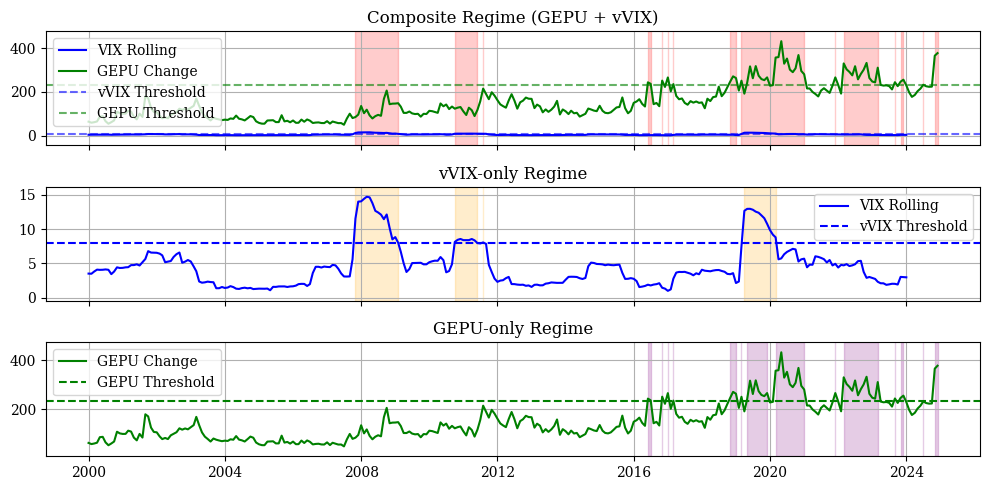

In [ ]:
from tqdm import tqdm

best_threshold_pair = (None, None)

Y = data_log[['wti_spot_real', 'wti_prod', 'INDPRO', 'ng_spot_real', 'lng_export',
                     'GEPU_current', 'VIX_rolling_vol']].dropna()
vix_var = data_log['VIX_rolling_vol'].dropna()
gepu_var = data_log['GEPU_current'].dropna()
selected_lag = selected_lag

vix_threshold_grid = np.percentile(vix_var, np.arange(10, 90, 1))

best_threshold_vix = None
best_ssr_vix = np.inf

for thresh in tqdm(vix_threshold_grid, desc="VIX Threshold Search"):
    low = Y[vix_var <= thresh]
    high = Y[vix_var > thresh]

    if len(low) > selected_lag and len(high) > selected_lag:
        try:
            model_low = VAR(low).fit(selected_lag)
            model_high = VAR(high).fit(selected_lag)

            ssr = np.sum(model_low.resid.values**2) + np.sum(model_high.resid.values**2)

            if ssr < best_ssr_vix:
                best_ssr_vix = ssr
                best_threshold_vix = thresh

        except:
            continue

print(f"Best VIX Threshold: {best_threshold_vix:.4f}")

gepu_threshold_grid = np.percentile(gepu_var, np.arange(15, 85, 1))

best_threshold_gepu = None
best_ssr_gepu = np.inf

best_ssr_gepu = float('inf')

for thresh in tqdm(gepu_threshold_grid, desc="GEPU Threshold Search"):
    low = Y[gepu_var <= thresh]
    high = Y[gepu_var > thresh]

    if len(low) > selected_lag and len(high) > selected_lag:
        try:
            model_low = VAR(low).fit(selected_lag)
            model_high = VAR(high).fit(selected_lag)

            ssr = np.sum(model_low.resid.values**2) + np.sum(model_high.resid.values**2)
            if ssr < best_ssr_gepu:
                best_ssr_gepu = ssr
                best_threshold_gepu = thresh

        except:
            continue

if best_threshold_gepu is not None:
    print(f"Best GEPU Threshold: {best_threshold_gepu:.4f}")
else:
    print("No suitable GEPU threshold found.")

best_threshold_pair = (best_threshold_gepu, best_threshold_vix)

gepu_thresh, vix_thresh = best_threshold_pair
vix_only_thresh = best_threshold_vix
gepu_only_thresh = best_threshold_gepu

data_log['regime_composite'] = np.where(
    (data_log['GEPU_current'] > gepu_thresh) | (data_log['VIX_rolling_vol'] > vix_thresh), 1, 0)

data_log['regime_vix'] = np.where(data_log['VIX_rolling_vol'] > vix_only_thresh, 1, 0)

if gepu_only_thresh is not None:
    data_log['regime_gepu'] = np.where(data_log['GEPU_current'] > gepu_only_thresh, 1, 0)
else:
    data_log['regime_gepu'] = 0


fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
axes[0].plot(data_log.index, data_log['VIX_rolling_vol'], label='VIX Rolling', color='blue')
axes[0].plot(data_log.index, data_log['GEPU_current'], label='GEPU Change', color='green')
axes[0].axhline(y=vix_thresh, color='blue', linestyle='--', alpha=0.6, label='vVIX Threshold')
axes[0].axhline(y=gepu_thresh, color='green', linestyle='--', alpha=0.6, label='GEPU Threshold')
axes[0].fill_between(data_log.index, 0, 1,
                     where=data_log['regime_composite'] == 1,
                     color='red', alpha=0.2, transform=axes[0].get_xaxis_transform())
axes[0].set_title('Composite Regime (GEPU + vVIX)')
axes[0].legend()
axes[0].grid(True)

# VIX-only Regime Plot
axes[1].plot(data_log.index, data_log['VIX_rolling_vol'], label='VIX Rolling', color='blue')
axes[1].axhline(y=vix_only_thresh, color='blue', linestyle='--', label='vVIX Threshold')
axes[1].fill_between(data_log.index, 0, 1,
                     where=data_log['regime_vix'] == 1,
                     color='orange', alpha=0.2, transform=axes[1].get_xaxis_transform())
axes[1].set_title('vVIX-only Regime')
axes[1].legend()
axes[1].grid(True)

# GEPU-only Regime Plot
axes[2].plot(data_log.index, data_log['GEPU_current'], label='GEPU Change', color='green')

if gepu_only_thresh is not None:
    axes[2].axhline(y=gepu_only_thresh, color='green', linestyle='--', label='GEPU Threshold')

axes[2].fill_between(data_log.index, 0, 1,
                     where=data_log['regime_gepu'] == 1,
                     color='purple', alpha=0.2, transform=axes[2].get_xaxis_transform())
axes[2].set_title('GEPU-only Regime')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
data_log.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 300 entries, 2024-12-01 to 2000-01-01
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   wti_spot_real     300 non-null    float64
 1   wti_prod          300 non-null    float64
 2   INDPRO            300 non-null    float64
 3   ng_spot_real      300 non-null    float64
 4   lng_export        300 non-null    float64
 5   GEPU_current      300 non-null    float64
 6   VIXCLS            300 non-null    float64
 7   VIX_rolling_vol   289 non-null    float64
 8   regime_composite  300 non-null    int64  
 9   regime_vix        300 non-null    int64  
 10  regime_gepu       300 non-null    int64  
dtypes: float64(8), int64(3)
memory usage: 28.1 KB


## **stationarity test**

In [ ]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):

    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'Variable': name,
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Stationary?': 'Yes' if result[1] < 0.05 else 'No'}

float_cols = data_log.select_dtypes(include=['float64']).columns
adf_results = [adf_test(data_log[col], col) for col in float_cols]
adf_df = pd.DataFrame(adf_results)
print("ADF Test Results for Float Columns:")
print(adf_df)

ADF Test Results for Float Columns:
          Variable  ADF Statistic       p-value Stationary?
0    wti_spot_real      -2.527000  1.090423e-01          No
1         wti_prod      -1.580834  4.932139e-01          No
2           INDPRO      -1.959334  3.046833e-01          No
3     ng_spot_real      -2.577924  9.764628e-02          No
4       lng_export      -2.211233  2.021939e-01          No
5     GEPU_current      -2.130622  2.323807e-01          No
6           VIXCLS      -5.708192  7.403996e-07         Yes
7  VIX_rolling_vol      -3.355450  1.257462e-02         Yes


In [ ]:
data_log.columns

Index(['wti_spot_real', 'wti_prod', 'INDPRO', 'ng_spot_real', 'lng_export',
       'GEPU_current', 'VIXCLS', 'VIX_rolling_vol', 'regime_composite',
       'regime_vix', 'regime_gepu'],
      dtype='object')

## **Stationarize non stationarity variables**

In [ ]:
data_log['wti_spot_diff'] = data_log['wti_spot_real'].diff()
data_log['ng_spot_diff'] = data_log['ng_spot_real'].diff()
data_log['wti_prod_diff'] = data_log['wti_prod'].diff()
data_log['INDPRO_diff'] = data_log['INDPRO'].diff()
data_log['lng_export_diff'] = data_log['lng_export'].diff()
data_log['GEPU_current_diff'] = data_log['GEPU_current'].diff()
data_log = data_log.drop(columns=['wti_spot_real', 'wti_prod',
                                  'INDPRO', 'GEPU_current',
                                  'lng_export', 'ng_spot_real'])

adf_results_diff = [adf_test(data_log[col], col) for col in ['wti_spot_diff', 'wti_prod_diff',
                                                             'INDPRO_diff', 'lng_export_diff',
                                                             'GEPU_current_diff', 'ng_spot_diff']]
adf_df_diff = pd.DataFrame(adf_results_diff)
print("ADF Test Results for Differenced Variables:")
print(adf_df_diff)

ADF Test Results for Differenced Variables:
            Variable  ADF Statistic       p-value Stationary?
0      wti_spot_diff     -11.923648  4.964940e-22         Yes
1      wti_prod_diff      -4.069825  1.085934e-03         Yes
2        INDPRO_diff     -13.241174  9.164673e-25         Yes
3    lng_export_diff      -3.233479  1.812673e-02         Yes
4  GEPU_current_diff      -6.322243  3.046064e-08         Yes
5       ng_spot_diff     -17.967161  2.803817e-30         Yes


In [ ]:
stationary_cols = ['VIX_rolling_vol', 'regime_composite']
stationary_data = data_log[stationary_cols]

data_stationary = pd.concat([stationary_data,
                             data_log[['wti_spot_diff', 'wti_prod_diff', 'INDPRO_diff',
                                       'lng_export_diff', 'GEPU_current_diff', 'ng_spot_diff']]],
                            axis=1).dropna()

print(data_stationary.head())

            VIX_rolling_vol  regime_composite  wti_spot_diff  wti_prod_diff  \
Month                                                                         
2024-01-01         2.956676                 0      -0.037001       0.023927   
2023-12-01         2.989513                 1      -0.027390       0.058357   
2023-11-01         3.019423                 1       0.079551      -0.034811   
2023-10-01         1.909617                 0       0.098836       0.022784   
2023-09-01         2.006613                 1       0.044211      -0.030678   

            INDPRO_diff  lng_export_diff  GEPU_current_diff  ng_spot_diff  
Month                                                                      
2024-01-01    -0.012181         0.097181          32.343680      0.618513  
2023-12-01     0.011248         0.065148          26.080980     -0.229198  
2023-11-01     0.002490        -0.090703          -9.027688      0.074791  
2023-10-01    -0.003005        -0.004824         -20.634690      0

In [ ]:
data_stationary.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 289 entries, 2024-01-01 to 2000-01-01
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   VIX_rolling_vol    289 non-null    float64
 1   regime_composite   289 non-null    int64  
 2   wti_spot_diff      289 non-null    float64
 3   wti_prod_diff      289 non-null    float64
 4   INDPRO_diff        289 non-null    float64
 5   lng_export_diff    289 non-null    float64
 6   GEPU_current_diff  289 non-null    float64
 7   ng_spot_diff       289 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 20.3 KB


## **Hansen test**

In [ ]:
def hansen_threshold_test(Y, threshold_var, lag_order=selected_lag, grid_points=100):

    if isinstance(threshold_var, pd.DataFrame):
        raise ValueError("threshold_var must be a single Series, not a DataFrame.")
    threshold_var = threshold_var.loc[Y.index]

    if threshold_var.nunique() < 20:
        raise ValueError("threshold_var appears to be categorical. Hansen threshold test requires a continuous variable.")

    data = pd.concat([Y, threshold_var.rename("threshold")], axis=1).dropna()
    Y = data[Y.columns]
    threshold_var = data["threshold"]

    thresholds = np.percentile(threshold_var, np.linspace(10, 90, grid_points))

    best_threshold = None
    best_ssr = np.inf

    for thresh in thresholds:
        low_regime = Y[threshold_var <= thresh]
        high_regime = Y[threshold_var > thresh]

        if len(low_regime) < lag_order * 2 or len(high_regime) < lag_order * 2:
            continue

        try:
            var_low = VAR(low_regime).fit(lag_order)
            var_high = VAR(high_regime).fit(lag_order)

            ssr = np.sum(var_low.resid.values**2) + np.sum(var_high.resid.values**2)

            if ssr < best_ssr:
                best_ssr = ssr
                best_threshold = thresh
        except Exception as e:
            continue

    linear_var = VAR(Y).fit(lag_order)
    linear_ssr = np.sum(linear_var.resid.values**2)

    LR = len(Y) * (linear_ssr - best_ssr) / linear_ssr

    critical_values = {0.10: 6.53, 0.05: 8.48, 0.01: 12.35}
    p_value = np.mean([LR > cv for cv in critical_values.values()])

    return {
        "best_threshold": best_threshold,
        "LR_statistic": LR,
        "critical_values": critical_values,
        "p_value": p_value,
        "reject_linear": LR > critical_values[0.05]}

In [ ]:
Y = data_stationary[['ng_spot_diff', 'wti_spot_diff', 'wti_prod_diff',
                     'INDPRO_diff', 'lng_export_diff', 'GEPU_current_diff']]
threshold_var = data_stationary['VIX_rolling_vol']

results = hansen_threshold_test(Y, threshold_var, lag_order=3)
print(results)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsm

{'best_threshold': np.float64(7.893483693215908), 'LR_statistic': np.float64(51.45191799787269), 'critical_values': {0.1: 6.53, 0.05: 8.48, 0.01: 12.35}, 'p_value': np.float64(1.0), 'reject_linear': np.True_}


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsm

## **BDS test**

In [ ]:
from statsmodels.tsa.stattools import bds

# Assuming data_stationary is already defined (see previous code)
model = VAR(data_stationary[['ng_spot_diff', 'wti_spot_diff', 'wti_prod_diff',
                             'INDPRO_diff', 'lng_export_diff', 'GEPU_current_diff','VIX_rolling_vol']])
results = model.fit(maxlags=selected_lag)  # You might need to adjust the lag order

# Perform BDS test on each column of Y
for col in Y.columns:
    bds_result = bds(Y[col], max_dim=5)
    print(f"BDS Test Results for {col}:\n{bds_result}\n")

BDS Test Results for ng_spot_diff:
(array([1.61300997, 1.79131382, 2.07692509, 2.09045314]), array([0.10674234, 0.07324295, 0.03780847, 0.03657711]))

BDS Test Results for wti_spot_diff:
(array([7.11351882, 6.62368277, 6.55408058, 6.27188527]), array([1.13121051e-12, 3.50358243e-11, 5.59857309e-11, 3.56702393e-10]))

BDS Test Results for wti_prod_diff:
(array([10.41044695,  8.64889196,  7.34462459,  6.46819423]), array([2.22176075e-25, 5.20018641e-18, 2.06337413e-13, 9.91809623e-11]))

BDS Test Results for INDPRO_diff:
(array([8.50783207, 8.81671035, 8.90452968, 8.6713042 ]), array([1.77215615e-17, 1.17871643e-18, 5.36128650e-19, 4.27198716e-18]))

BDS Test Results for lng_export_diff:
(array([ 8.84725761, 10.76328601, 10.93863227, 11.1205475 ]), array([8.96961804e-19, 5.13073654e-27, 7.53277042e-28, 9.96585225e-29]))

BDS Test Results for GEPU_current_diff:
(array([4.56356108, 6.26484517, 7.22932794, 7.77141814]), array([5.02931678e-06, 3.73196029e-10, 4.85390040e-13, 7.76122292e-15])

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency -1MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


## **TVAR model**

In [ ]:
low_regime = data_stationary[data_stationary['regime_composite'] == 0]
high_regime = data_stationary[data_stationary['regime_composite'] == 1]

# low-uncertainty regime

var_low = VAR(low_regime.drop(columns=['regime_composite']))  # Exclude threshold variable
results_low = var_low.fit(maxlags=selected_lag)
print(results_low.summary())

# high-uncertainty regime
var_high = VAR(high_regime.drop(columns=['regime_composite']))
results_high = var_high.fit(maxlags=selected_lag)
print(results_high.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 01, May, 2025
Time:                     08:40:53
--------------------------------------------------------------------
No. of Equations:         7.00000    BIC:                   -17.5338
Nobs:                     213.000    HQIC:                  -18.5211
Log likelihood:           33.1804    FPE:                4.63726e-09
AIC:                     -19.1908    Det(Omega_mle):     2.87988e-09
--------------------------------------------------------------------
Results for equation VIX_rolling_vol
                          coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------------
const                        0.360912         0.105177            3.431           0.001
L1.VIX_rolling_vol           1.131839         0.068273           16.578           0.000
L1.wti_spot_diff      

## **Impulse response functions**

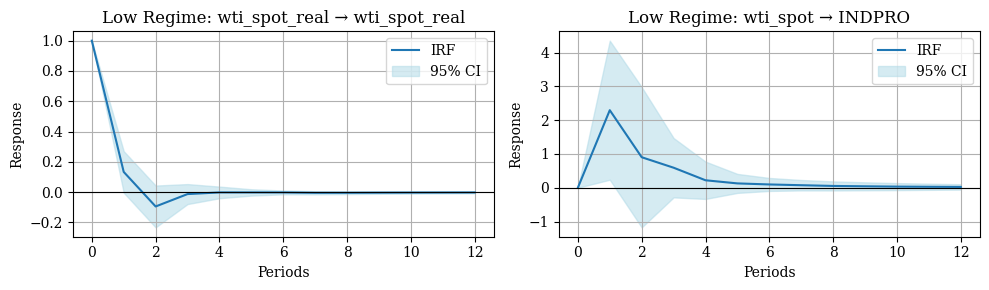

In [ ]:
horizon = 12
irf = results_low.irf(horizon)

var_names = results_low.names
get_idx = lambda name: var_names.index(name)

wti_idx = get_idx('wti_spot_diff')
indpro_idx = get_idx('INDPRO_diff')

significant_pairs = [
    (wti_idx, wti_idx, 'wti_spot_real → wti_spot_real'),
    (wti_idx, indpro_idx, 'wti_spot → INDPRO')]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

stderr = irf.stderr(orth=False)
periods = np.arange(horizon + 1)

for i, (shock_idx, response_idx, label) in enumerate(significant_pairs):

    response = irf.irfs[:, shock_idx, response_idx]
    lower = response - 1.96 * stderr[:, shock_idx, response_idx]
    upper = response + 1.96 * stderr[:, shock_idx, response_idx]

    axes[i].plot(periods, response, label='IRF')
    axes[i].fill_between(periods, lower, upper, color='lightblue', alpha=0.5, label='95% CI')
    axes[i].set_title(f'Low Regime: {label}')
    axes[i].axhline(0, color='black', linewidth=0.8)
    axes[i].legend()
    axes[i].grid(True)
    axes[i].set_xlabel('Periods')
    axes[i].set_ylabel('Response')

plt.tight_layout()
plt.show()

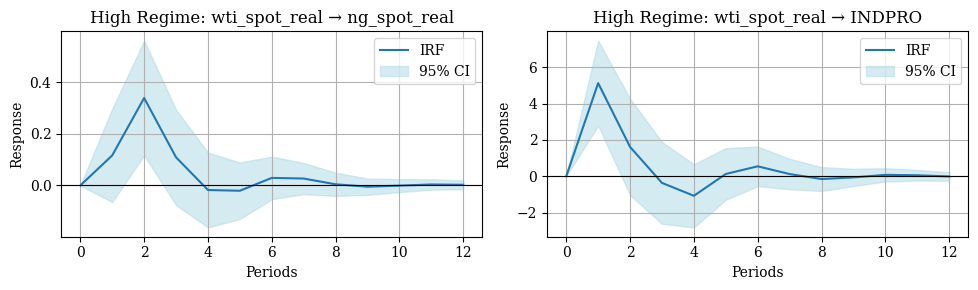

In [ ]:
horizon = 12
irf = results_high.irf(horizon)

var_names = results_high.names
get_idx = lambda name: var_names.index(name)

ng_idx = get_idx('ng_spot_diff')
indpro_idx = get_idx('INDPRO_diff')

significant_pairs = [
    (wti_idx, ng_idx, 'wti_spot_real → ng_spot_real'),
    (wti_idx, indpro_idx, 'wti_spot_real → INDPRO')]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

stderr = irf.stderr(orth=False)
periods = np.arange(horizon + 1)

for i, (shock_idx, response_idx, label) in enumerate(significant_pairs):

    response = irf.irfs[:, shock_idx, response_idx]
    lower = response - 1.96 * stderr[:, shock_idx, response_idx]
    upper = response + 1.96 * stderr[:, shock_idx, response_idx]

    axes[i].plot(periods, response, label='IRF')
    axes[i].fill_between(periods, lower, upper, color='lightblue', alpha=0.5, label='95% CI')
    axes[i].set_title(f'High Regime: {label}')
    axes[i].axhline(0, color='black', linewidth=0.8)
    axes[i].legend()
    axes[i].grid(True)
    axes[i].set_xlabel('Periods')
    axes[i].set_ylabel('Response')

plt.tight_layout()
plt.show()

## **Breakpoint detection**

In [ ]:
!pip install ruptures
import ruptures as rpt

In [ ]:
data = high_regime[['wti_spot_diff', 'INDPRO_diff', 'ng_spot_diff']].values

algo = rpt.Pelt(model="rbf").fit(data)
breaks = algo.predict(pen=5)
print(f"Breakpoints at observations: {breaks}")

Breakpoints at observations: [74]


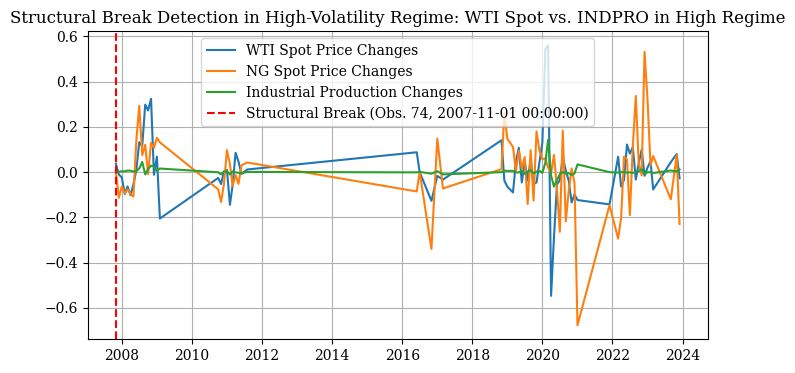

Breakpoints at observations: [74]


In [ ]:
algo = rpt.Pelt(model="l1").fit(data)
breaks = algo.predict(pen=2)

plt.figure(figsize=(8, 4))
plt.plot(high_regime.index, high_regime['wti_spot_diff'], label='WTI Spot Price Changes')
plt.plot(high_regime.index, high_regime['ng_spot_diff'], label='NG Spot Price Changes')
plt.plot(high_regime.index, high_regime['INDPRO_diff'], label='Industrial Production Changes')

break_date = high_regime.index[73]
plt.axvline(x=break_date, color='red', linestyle='--',
            label=f'Structural Break (Obs. 74, {break_date})')
plt.title('Structural Break Detection in High-Volatility Regime: WTI Spot vs. INDPRO in High Regime')
plt.legend(loc='upper center')
plt.grid()
plt.show()

print(f"Breakpoints at observations: {breaks}")

In [ ]:
break_date = high_regime.index[73]
print(f"Structural break detected at: {break_date}")

Structural break detected at: 2007-11-01 00:00:00


Breakpoints: [15, 25, 60, 65, 74]


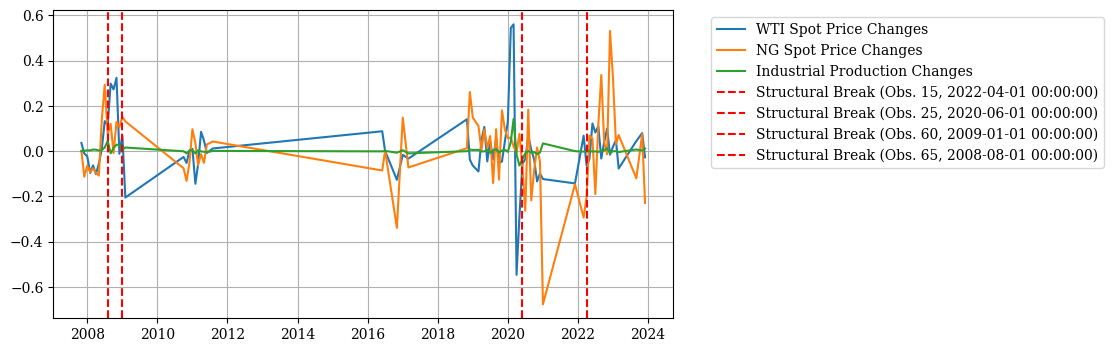

In [ ]:
algo = rpt.Dynp(model="l1").fit(data)
breaks_dynp = algo.predict(n_bkps=4)
print(f"Breakpoints: {breaks_dynp}")

plt.figure(figsize=(8, 4))
plt.plot(high_regime.index, high_regime['wti_spot_diff'], label='WTI Spot Price Changes')
plt.plot(high_regime.index, high_regime['ng_spot_diff'], label='NG Spot Price Changes')
plt.plot(high_regime.index, high_regime['INDPRO_diff'], label='Industrial Production Changes')

for break_point in breaks_dynp[:-1]:
    break_date = high_regime.index[break_point - 1]
    plt.axvline(x=break_date, color='red', linestyle='--',
                label=f'Structural Break (Obs. {break_point}, {break_date})')

plt.grid()

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
threshold = 0.01

data = high_regime[['wti_spot_diff', 'INDPRO_diff', 'ng_spot_diff']].values
data = pd.DataFrame(data, columns=['wti_spot_diff', 'INDPRO_diff', 'ng_spot_diff'],
                    index=high_regime.index)
data['price_change'] = data['wti_spot_diff']
data['pos_shock'] = (data['price_change'] > threshold).astype(int)
data['neg_shock'] = (data['price_change'] < -threshold).astype(int)

results_high = VAR(data[['wti_spot_diff', 'INDPRO_diff', 'ng_spot_diff', 'pos_shock', 'neg_shock']]).fit(maxlags=selected_lag)

irf = results_high.irf(12)

irf_pos_shock = irf.irfs[:, results_high.names.index('pos_shock'),
                 results_high.names.index('wti_spot_diff')]
irf_neg_shock = irf.irfs[:, results_high.names.index('neg_shock'),
                 results_high.names.index('wti_spot_diff')]

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


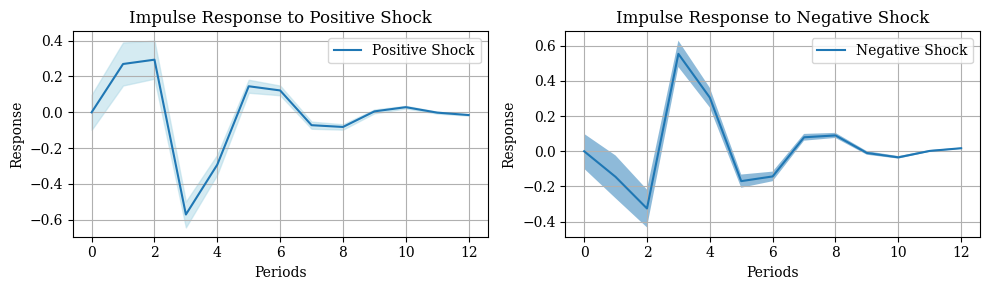

In [ ]:
stderr_pos_shock = irf.stderr(orth=True)[:, results_high.names.index('pos_shock'),
                                      results_high.names.index('wti_spot_diff')]
stderr_neg_shock = irf.stderr(orth=True)[:, results_high.names.index('neg_shock'),
                                      results_high.names.index('wti_spot_diff')]

lower_pos_shock = irf_pos_shock - 1.96 * stderr_pos_shock
upper_pos_shock = irf_pos_shock + 1.96 * stderr_pos_shock
lower_neg_shock = irf_neg_shock - 1.96 * stderr_neg_shock
upper_neg_shock = irf_neg_shock + 1.96 * stderr_neg_shock

periods = np.arange(len(irf_pos_shock))
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

axes[0].plot(periods, irf_pos_shock, label='Positive Shock')
axes[0].fill_between(periods, lower_pos_shock, upper_pos_shock, color='lightblue', alpha=0.5)
axes[0].set_title('Impulse Response to Positive Shock')
axes[0].set_xlabel('Periods')
axes[0].set_ylabel('Response')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(periods, irf_neg_shock, label='Negative Shock')
axes[1].fill_between(periods, lower_neg_shock, upper_neg_shock, alpha=0.5)
axes[1].set_title('Impulse Response to Negative Shock')
axes[1].set_xlabel('Periods')
axes[1].set_ylabel('Response')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()